In [1]:
import os

# Make only GPU 7 visible to TensorFlow
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import tensorflow as tf

# List the visible GPUs (GPU 7 will appear as GPU 0 to TensorFlow)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Allow memory growth instead of setting a fixed limit
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(f"Using GPU 3 (seen as GPU 0 by TF): {len(gpus)} physical, {len(logical_gpus)} logical GPUs")
    except RuntimeError as e:
        print("TF GPU setup error:", e)
else:
    print("No GPU available. Running on CPU.")

2025-12-09 16:21:48.183316: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-09 16:21:48.914427: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Using GPU 3 (seen as GPU 0 by TF): 1 physical, 1 logical GPUs


2025-12-09 16:21:50.215441: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20763 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:35:00.0, compute capability: 8.9


In [2]:
import os
import cv2
import numpy as np
import pywt
import scipy.stats
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from skimage.feature import graycomatrix, graycoprops
from tensorflow.keras.utils import to_categorical
import umap
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Concatenate, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.tree import DecisionTreeClassifier, _tree, plot_tree
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
import itertools
import tqdm
from transformers import TFViTModel, ViTFeatureExtractor
import gc



In [3]:

# --- CONFIGURATION ---

IMG_SIZE = (224, 224)
WAVELET = 'db1'
RESULT_PATH = './CC-D3r7-Latest'

def parse_respath(*pathfrag):
    path = os.path.join(RESULT_PATH, *pathfrag)
    os.makedirs(os.path.dirname(path), exist_ok=True)
    return path

In [4]:
# BC prefix => borrowed code

class BC_FeatureExtractor:

    @staticmethod
    def _wavelet_stats(subband):
        return [
            np.mean(subband),
            np.std(subband),
            np.var(subband),
            scipy.stats.entropy(np.abs(subband.flatten()) + 1e-6)
        ]

    @classmethod
    def extract_wavelet_stats(cls, image, wavelet='db1'):
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        coeffs2 = pywt.dwt2(gray, wavelet)
        LL, (LH, HL, HH) = coeffs2
        features = list()
        for band in [LL, LH, HL, HH]:
            features.extend(cls._wavelet_stats(band))
        hh_energy = np.sum(np.square(HH))
        features.append(hh_energy)
        return features

    @staticmethod
    def extract_glcm_features_extended(image):
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        angles = [0, np.pi/4, np.pi/2]
        glcm = graycomatrix(gray, distances=[5], angles=angles, levels=256, symmetric=True, normed=True)
        contrast = graycoprops(glcm, 'contrast').mean()
        dissimilarity = graycoprops(glcm, 'dissimilarity').mean()
        homogeneity = graycoprops(glcm, 'homogeneity').mean()
        return [contrast, dissimilarity, homogeneity]


In [5]:
import csv, os
from collections import namedtuple

class BaseDataDir:
        
    def _assert_files(self):
        discard = list()
        for i, f in enumerate(self.files):
            if not os.path.exists(f):
                print(f'warning: cannot resolve file {f}')
                discard.append(i)
        for i in reversed(discard):
            self.files.pop(i)

    def get_label(self, i):
        path = self.files[i]
        return self.get_label_from_path(path)
    
    def load(self, i):
        path = self.files[i]
        label = self.get_label_from_path(path)
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # img = img[30:430, 200:550]
        img = cv2.resize(img, IMG_SIZE)
        features = list()
        features.extend(BC_FeatureExtractor.extract_wavelet_stats(img, wavelet=WAVELET))
        features.extend(BC_FeatureExtractor.extract_glcm_features_extended(img))
        return img, features, label

    def imshows4(self, indices):
        fig, axs = plt.subplots(2, 2, figsize=(8, 4*2))
        for n, i in enumerate(indices):
            img, _, _ = self.load(i)
            axs[n//2, n%2].imshow(img)
            # axs[n//2, n%2].set_title(self.files[i])
        return fig

In [6]:
class DataDirHyperKvasir(BaseDataDir):
    nt_labels = namedtuple('Label', ['organ','finding','classification','train_test'])

    def __init__(self, path):
        self.path = path
        self.labels = dict()
        self.files = list()
        self.nfiles = 0
        self._labels_csv_path = f'{path}/labeled-images/image-labels.csv'
        if not os.path.exists(self._labels_csv_path):
            raise FileNotFoundError('cant resolve labels csv file')
        with open(self._labels_csv_path) as fp:
            reader = csv.reader(fp)
            _ = next(reader) # ignore column header
            for filename, *row in reader:
                self.labels[filename] = self.nt_labels(*row, -1)
        self._images_path = f'{path}/labeled-images'
        for root, dirs, files in os.walk(self._images_path):
            if '.ipynb_checkpoints' in root: continue
            for f in files:
                if not f.endswith(('bmp', 'jpg', 'png', 'jpeg', 'jfif', 'webp')): continue
                if not f.rpartition('.')[0] in self.labels: continue
                self.files.append(os.path.join(root, f))
        self._assert_files()
        self.nfiles = len(self.files)
        print(f'found {self.nfiles} files')
        self.train_indices = np.array(range(self.nfiles))
        self.test_indices = None

    def get_label_from_path(self, path):
        filename = path.rpartition(os.path.sep)[-1].rpartition('.')[0]
        return self.labels[filename]

datadir_hyper = DataDirHyperKvasir('./Dataset/HyperKvasir')
# _ = datadir_hyper.imshows4(np.random.randint(0, datadir_hyper.nfiles, size=4))

found 10662 files


In [7]:
class DataDirTMCUCM(BaseDataDir):
    nt_labels = namedtuple('Label', ['MES','train_test'])

    def __init__(self, path, ignore_augment=True):
        self.path = path
        self.labels = dict()
        self.files = list()
        self.nfiles = 0
        self.train_indices = list()
        self.test_indices = list()

        self._labels_train_csv_path = f'{path}/train.txt'
        if not os.path.exists(self._labels_train_csv_path):
            raise FileNotFoundError('cant resolve labels csv file')
        with open(self._labels_train_csv_path) as fp:
            reader = csv.reader(fp, delimiter=' ')
            for filepath, mes in reader:
                if ignore_augment and 'augment' in filepath: continue
                filename = '/'.join(filepath.split('/')[-2:])
                self.labels[filename] = self.nt_labels(f'MES{int(mes)}', 0)
                self.files.append(f'{self.path}/{filename}')
                self.train_indices.append(len(self.files)-1)

        self._labels_test_csv_path = f'{path}/test.txt'
        if not os.path.exists(self._labels_test_csv_path):
            raise FileNotFoundError('cant resolve labels csv file')
        with open(self._labels_test_csv_path) as fp:
            reader = csv.reader(fp, delimiter=' ')
            for filepath, mes in reader:
                if ignore_augment and 'augment' in filepath: continue
                filename = '/'.join(filepath.split('/')[-2:])
                self.labels[filename] = self.nt_labels(f'MES{int(mes)}', 1)
                self.files.append(f'{self.path}/{filename}')
                self.test_indices.append(len(self.files)-1)
        self._assert_files()
        self.nfiles = len(self.files)
        print(f'found {self.nfiles} files')
        self.train_indices = np.array(self.train_indices)
        self.test_indices = np.array(self.test_indices)

    def get_label_from_path(self, path):
        filename = '/'.join(path.split('/')[-2:])
        return self.labels[filename]

    def load_indices(self, indices):
        imgs = list()
        features = list()
        labels = list()
        for i in tqdm.auto.tqdm(indices):
            img, feature, label = self.load(i)
            imgs.append(img)
            features.append(feature)
            labels.append(label[0])
        return np.array(imgs), np.array(features), np.array(labels)

datadir_tmcucm = DataDirTMCUCM('./Dataset/TMC-UCM')
# _ = datadir_tmcucm.imshows4(np.random.randint(0, datadir_tmcucm.nfiles, size=4))

found 7978 files


In [8]:
class DataDirLIMUC(BaseDataDir):
    nt_labels = namedtuple('Label', ['MES','train_test'])

    def __init__(self, path):
        self.path = path
        self.labels = dict()
        self.files = list()
        self.nfiles = 0
        self.train_indices = list()
        self.test_indices = list()
        self._dir_train = f'{path}/train_and_validation_sets'
        self._dir_test = f'{path}/test_set'

        for label in os.listdir(self._dir_train):
            subpath = os.path.join(self._dir_train, label)
            if not os.path.isdir(subpath): continue
            for f in os.listdir(subpath):
                if not f.endswith(('bmp', 'jpg', 'jpeg', 'png', 'jfif', 'webp')): continue
                filepath = os.path.join(subpath, f)
                self.files.append(filepath)
                key = '/'.join(filepath.split('/')[-2:])
                self.labels[key] = self.nt_labels('MES'+label[-1], -1)
        self.train_indices = range(len(self.files))

        for label in os.listdir(self._dir_test):
            subpath = os.path.join(self._dir_test, label)
            if not os.path.isdir(subpath): continue
            for f in os.listdir(subpath):
                if not f.endswith(('bmp', 'jpg', 'jpeg', 'png', 'jfif', 'webp')): continue
                filepath = os.path.join(subpath, f)
                self.files.append(filepath)
                key = '/'.join(filepath.split('/')[-2:])
                self.labels[key] = self.nt_labels('MES'+label[-1], -1)
        self.test_indices = range(len(self.train_indices), len(self.files))
        self._assert_files()
        self.nfiles = len(self.files)
        print(f'found {self.nfiles} files')
        self.train_indices = np.array(self.train_indices)
        self.test_indices = np.array(self.test_indices)


    def load(self, i):
        path = self.files[i]
        label = self.get_label_from_path(path)
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # print(img.shape)
        img = img[36+20:288-14-20, 22:352-16]
        img = cv2.resize(img, IMG_SIZE)
        features = list()
        features.extend(BC_FeatureExtractor.extract_wavelet_stats(img, wavelet=WAVELET))
        features.extend(BC_FeatureExtractor.extract_glcm_features_extended(img))
        return img, features, label

    def get_label_from_path(self, path):
        filename = '/'.join(path.split('/')[-2:])
        return self.labels[filename]

    def load_indices(self, indices):
        imgs = list()
        features = list()
        labels = list()
        for i in tqdm.auto.tqdm(indices):
            img, feature, label = self.load(i)
            imgs.append(img)
            features.append(feature)
            labels.append(label[0])
        return np.array(imgs), np.array(features), np.array(labels)

datadir_limuc = DataDirLIMUC('./Dataset/LIMUC')
# _ = datadir_limuc.imshows4(np.random.randint(0, datadir_limuc.nfiles, size=4))

datadir_limuc.train_indices.shape, datadir_limuc.test_indices.shape

found 11276 files


((9590,), (1686,))

In [9]:
class DataDirDefault(BaseDataDir):
    nt_labels = namedtuple('Label', ['MES','train_test'])

    def __init__(self, path):
        self.path = path
        self.labels = dict()
        self.files = list()
        self.nfiles = 0
        self.train_indices = list()
        self.test_indices = list()
        for label in os.listdir(self.path):
            subpath = os.path.join(self.path, label)
            if not os.path.isdir(subpath): continue
            for f in os.listdir(subpath):
                if not f.endswith(('bmp', 'jpg', 'jpeg', 'png', 'jfif', 'webp')): continue
                filepath = os.path.join(subpath, f)
                self.files.append(filepath)
                key = '/'.join(filepath.split('/')[-2:])
                self.labels[key] = self.nt_labels(label, -1)
        self._assert_files()
        self.nfiles = len(self.files)
        print(f'found {self.nfiles} files')
        self.train_indices = np.array(self.train_indices)
        self.test_indices = np.array(self.test_indices)

    def load(self, i):
        path = self.files[i]
        label = self.get_label_from_path(path)
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = img[30:430, 200:550]
        img = cv2.resize(img, IMG_SIZE)
        features = list()
        features.extend(BC_FeatureExtractor.extract_wavelet_stats(img, wavelet=WAVELET))
        features.extend(BC_FeatureExtractor.extract_glcm_features_extended(img))
        return img, features, label

    def get_label_from_path(self, path):
        filename = '/'.join(path.split('/')[-2:])
        return self.labels[filename]

    def load_indices(self, indices):
        imgs = list()
        features = list()
        labels = list()
        for i in tqdm.auto.tqdm(indices):
            img, feature, label = self.load(i)
            imgs.append(img)
            features.append(feature)
            labels.append(label[0])
        return np.array(imgs), np.array(features), np.array(labels)

datadir_mixed = DataDirDefault('./Dataset+Code/MES Mixed Data')

ls1 = set(os.listdir('./Dataset+Code/MES Mixed Data/MES1'))
ls2 = set(os.listdir('./Dataset+Code/MES Mixed Data/MES2'))
ls1.intersection(ls2)


found 997 files


{'.DS_Store',
 '6316984_20240927_ES_1_13_13.jpg',
 '6316984_20240927_ES_1_14_14.jpg'}

In [19]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from tensorflow.keras.utils import to_categorical
import umap
import matplotlib.pyplot as plt

print("🚀 MERGING DATASETS: LIMUC + TMC-UCM...")

# ==============================================================================
# 1. INSTANSIASI LOADER
# ==============================================================================
# Pastikan path folder benar sesuai struktur Colab/Local kamu
dir_limuc = DataDirLIMUC('./Dataset/LIMUC')
dir_tmc   = DataDirTMCUCM('./Dataset/TMC-UCM')

# ==============================================================================
# 2. LOAD & GABUNGKAN DATA (TRAIN & TEST)
# ==============================================================================
print("\n📥 Loading LIMUC Data...")
# Load LIMUC Train
lx_img_tr, lx_feat_tr, ly_tr = dir_limuc.load_indices(dir_limuc.train_indices)
# Load LIMUC Test
lx_img_ts, lx_feat_ts, ly_ts = dir_limuc.load_indices(dir_limuc.test_indices)

print("\n📥 Loading TMC-UCM Data...")
# Load TMC Train
tx_img_tr, tx_feat_tr, ty_tr = dir_tmc.load_indices(dir_tmc.train_indices)
# Load TMC Test
tx_img_ts, tx_feat_ts, ty_ts = dir_tmc.load_indices(dir_tmc.test_indices)


print("\n🔗 Concatenating Datasets...")
# --- GABUNG TRAIN ---
X_img_train_raw = np.concatenate([lx_img_tr, tx_img_tr], axis=0)
X_feat_train_raw = np.concatenate([lx_feat_tr, tx_feat_tr], axis=0)
y_train_label = np.concatenate([ly_tr, ty_tr], axis=0)

# --- GABUNG TEST ---
X_img_test_raw = np.concatenate([lx_img_ts, tx_img_ts], axis=0)
X_feat_test_raw = np.concatenate([lx_feat_ts, tx_feat_ts], axis=0)
y_test_label = np.concatenate([ly_ts, ty_ts], axis=0)

# Informasi Sumber (Opsional, untuk debugging)
sources_train = ['LIMUC']*len(lx_img_tr) + ['TMC']*len(tx_img_tr)

print(f"✅ TOTAL TRAIN SAMPLES: {len(X_img_train_raw)} (LIMUC: {len(lx_img_tr)}, TMC: {len(tx_img_tr)})")
print(f"✅ TOTAL TEST SAMPLES:  {len(X_img_test_raw)} (LIMUC: {len(lx_img_ts)}, TMC: {len(tx_img_ts)})")

# ==============================================================================
# 3. NORMALISASI & ENCODING
# ==============================================================================
# Normalize Images
X_img_train = X_img_train_raw.astype(np.float32) / 255.0
X_img_test = X_img_test_raw.astype(np.float32) / 255.0

# Label Encoding (Pastikan label string sama, misal "MES0", "MES1")
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_label)
y_test_encoded = le.transform(y_test_label) # Harus transform, jangan fit ulang

y_train_cat = to_categorical(y_train_encoded, num_classes=len(le.classes_))
y_test_cat = to_categorical(y_test_encoded, num_classes=len(le.classes_))

print(f"   Classes detected: {le.classes_}")

# ==============================================================================
# 4. FEATURE SCALING (StandardScaler)
# ==============================================================================
# Fit pada gabungan data train, transform pada train & test
scaler = StandardScaler()
X_feat_train_scaled = scaler.fit_transform(X_feat_train_raw)
X_feat_test_scaled = scaler.transform(X_feat_test_raw)

# ==============================================================================
# 5. SMOTE (BALANCING GABUNGAN)
# ==============================================================================
print("\n⚖️ Applying SMOTE to Combined Training Data...")
smote = SMOTE(random_state=42)
X_feat_train_bal, y_train_bal = smote.fit_resample(X_feat_train_scaled, y_train_encoded)

# Mapping Balik SMOTE Features ke Gambar Asli (Nearest Neighbor)
# (Karena SMOTE membuat fitur sintetik, kita pinjam gambar asli yg paling mirip)
print("   🖼️ Mapping Balanced Features to Images...")
X_img_train_bal = []

# Optimasi: Pre-grouping untuk mempercepat pencarian
train_feats_by_class = {}
train_imgs_by_class = {}
for cls in np.unique(y_train_encoded):
    mask = (y_train_encoded == cls)
    train_feats_by_class[cls] = X_feat_train_scaled[mask]
    train_imgs_by_class[cls] = X_img_train[mask]

for feat, label in zip(X_feat_train_bal, y_train_bal):
    candidates = train_feats_by_class[label]
    candidate_imgs = train_imgs_by_class[label]
    dists = np.linalg.norm(candidates - feat, axis=1)
    idx = np.argmin(dists)
    X_img_train_bal.append(candidate_imgs[idx])

X_img_train_bal = np.array(X_img_train_bal, dtype=np.float32)
y_train_cat_bal = to_categorical(y_train_bal, num_classes=len(le.classes_))

# ==============================================================================
# 6. UMAP PROJECTION (Pada Data Gabungan Balanced)
# ==============================================================================
print("\n🗺️ Generating UMAP Projection...")
# Gunakan parameter n_neighbors agak besar karena data gabungan lebih padat
umap_reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=2, metric='euclidean', random_state=42)

X_train_umap = umap_reducer.fit_transform(X_feat_train_bal)
X_test_umap = umap_reducer.transform(X_feat_test_scaled) # Transform data test

# --- SHAPE SUMMARY ---
print("\n✅ DATA PREPARATION COMPLETE.")
print(f"   X_img_train_bal:  {X_img_train_bal.shape}")
print(f"   X_feat_train_bal: {X_feat_train_bal.shape}")
print(f"   X_train_umap:     {X_train_umap.shape}")
print(f"   y_train_bal:      {y_train_bal.shape}")




🚀 MERGING DATASETS: LIMUC + TMC-UCM...
found 11276 files
found 7978 files

📥 Loading LIMUC Data...


  0%|          | 0/9590 [00:00<?, ?it/s]

  0%|          | 0/1686 [00:00<?, ?it/s]


📥 Loading TMC-UCM Data...


  0%|          | 0/4787 [00:00<?, ?it/s]

  0%|          | 0/3191 [00:00<?, ?it/s]


🔗 Concatenating Datasets...
✅ TOTAL TRAIN SAMPLES: 14377 (LIMUC: 9590, TMC: 4787)
✅ TOTAL TEST SAMPLES:  4877 (LIMUC: 1686, TMC: 3191)
   Classes detected: ['MES0' 'MES1' 'MES2' 'MES3']

⚖️ Applying SMOTE to Combined Training Data...
   🖼️ Mapping Balanced Features to Images...

🗺️ Generating UMAP Projection...


/home/ubuntu/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/ubuntu/.local/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)



✅ DATA PREPARATION COMPLETE.
   X_img_train_bal:  (27996, 224, 224, 3)
   X_feat_train_bal: (27996, 20)
   X_train_umap:     (27996, 2)
   y_train_bal:      (27996,)


In [11]:
import os
import joblib
import numpy as np

# Tentukan folder penyimpanan (bisa di Drive biar permanen)
CACHE_DIR = './MIX_TMC-LIMUC'
os.makedirs(CACHE_DIR, exist_ok=True)

print(f"💾 Saving processed data to {CACHE_DIR}...")

# 1. Simpan Array Data (Compressed agar hemat storage)
# Kita pecah jadi Train dan Test agar manajemen memori lebih mudah
np.savez_compressed(
    os.path.join(CACHE_DIR, 'train_data_balanced.npz'),
    X_img=X_img_train_bal,
    X_feat=X_feat_train_bal,
    X_umap=X_train_umap,
    y_label=y_train_bal,
    y_cat=y_train_cat_bal
)

np.savez_compressed(
    os.path.join(CACHE_DIR, 'test_data.npz'),
    X_img=X_img_test,
    X_feat=X_feat_test_scaled, # Ingat, yang test cuma di-scale, tidak di-bal
    X_umap=X_test_umap,
    y_encoded=y_test_encoded,
    y_cat=y_test_cat
)

# 2. Simpan Objects (Scaler, Encoder, UMAP, SMOTE)
# Ini PENTING agar nanti bisa dipakai untuk prediksi data baru
joblib.dump(scaler, os.path.join(CACHE_DIR, 'scaler.pkl'))
joblib.dump(le, os.path.join(CACHE_DIR, 'label_encoder.pkl'))
joblib.dump(umap_reducer, os.path.join(CACHE_DIR, 'umap_reducer.pkl'))
# smote tidak perlu disimpan karena hanya dipakai training sekali

print("✅ SUKSES! Semua data berhasil disimpan.")
print("   Besok kalau mau run lagi, tinggal Load saja (skip proses Merging/SMOTE).")

💾 Saving processed data to ./MIX_TMC-LIMUC...


NameError: name 'X_img_train_bal' is not defined

In [ ]:
import os
import joblib
import numpy as np
import tensorflow as tf

CACHE_DIR = './MIX_TMC-LIMUC'

# Cek apakah file cache ada
if os.path.exists(os.path.join(CACHE_DIR, 'train_data_balanced.npz')):
    print("🚀 FOUND CACHED DATA! Loading directly (Skipping SMOTE/UMAP)...")

    # 1. Load Train Data
    print("   📥 Loading Training Data...")
    train_data = np.load(os.path.join(CACHE_DIR, 'train_data_balanced.npz'))
    X_img_train_bal = train_data['X_img']
    X_feat_train_bal = train_data['X_feat']
    X_train_umap = train_data['X_umap']
    y_train_bal = train_data['y_label']
    y_train_cat_bal = train_data['y_cat']

    # 2. Load Test Data
    print("   📥 Loading Test Data...")
    test_data = np.load(os.path.join(CACHE_DIR, 'test_data.npz'))
    X_img_test = test_data['X_img']
    X_feat_test_scaled = test_data['X_feat']
    X_test_umap = test_data['X_umap']
    y_test_encoded = test_data['y_encoded']
    y_test_cat = test_data['y_cat']

    # 3. Load Objects
    print("   tools Loading Scalers & Encoders...")
    scaler = joblib.load(os.path.join(CACHE_DIR, 'scaler.pkl'))
    le = joblib.load(os.path.join(CACHE_DIR, 'label_encoder.pkl'))
    umap_reducer = joblib.load(os.path.join(CACHE_DIR, 'umap_reducer.pkl'))

    print(f"✅ LOAD COMPLETE!")
    print(f"   Train Shape: {X_img_train_bal.shape}")
    print(f"   Test Shape:  {X_img_test.shape}")

else:
    print("❌ CACHE NOT FOUND. Harap jalankan cell 'Merging Datasets' yang asli terlebih dahulu untuk membuat cache.")
    # Di sini kamu bisa raise error atau print instruksi agar user menjalankan cell processing manual

In [ ]:
# plt.imshow(datadir_mixed.load(1)[0])

In [12]:
# --- MOD-SE(2) CNN (UNCHANGED) ---
def z2_se2n(input_tensor, kernel, orientations_nb, periodicity=2 * np.pi, diskMask=True, padding='VALID'):
    print("Base Kernel:\n", kernel.numpy())
    kernel_stack = rotate_lifting_kernels(kernel, orientations_nb, periodicity=periodicity, diskMask=diskMask)
    print("Z2-SE2N ROTATED KERNEL SET SHAPE:", kernel_stack.get_shape())
    kernels_as_if_2D = tf.transpose(kernel_stack, [1, 2, 3, 0, 4])
    kernelSizeH, kernelSizeW, channelsIN, channelsOUT = map(int, kernel.shape)
    kernels_as_if_2D = tf.reshape(kernels_as_if_2D, [kernelSizeH, kernelSizeW, channelsIN, orientations_nb * channelsOUT])
    layer_output = tf.nn.conv2d(input=input_tensor, filters=kernels_as_if_2D, strides=[1, 1, 1, 1], padding=padding)
    layer_output = tf.reshape(layer_output, [tf.shape(layer_output)[0], int(layer_output.shape[1]), int(layer_output.shape[2]), orientations_nb, channelsOUT])
    print("OUTPUT SE2N ACTIVATIONS SHAPE:", layer_output.get_shape())
    return layer_output, kernel_stack

def se2n_se2n(input_tensor, kernel, periodicity=2 * np.pi, diskMask=True, padding='VALID'):
    kernelSizeH, kernelSizeW, orientations_nb, channelsIN, channelsOUT = map(int, kernel.shape)
    kernel_stack = rotate_gconv_kernels(kernel, periodicity, diskMask)
    print("SE2N-SE2N ROTATED KERNEL SET SHAPE:", kernel_stack.get_shape())
    input_tensor_as_if_2D = tf.reshape(input_tensor, [tf.shape(input_tensor)[0], int(input_tensor.shape[1]), int(input_tensor.shape[2]), orientations_nb * channelsIN])
    kernels_as_if_2D = tf.transpose(kernel_stack, [1, 2, 3, 4, 0, 5])
    kernels_as_if_2D = tf.reshape(kernels_as_if_2D, [kernelSizeH, kernelSizeW, orientations_nb * channelsIN, orientations_nb * channelsOUT])
    layer_output = tf.nn.conv2d(input=input_tensor_as_if_2D, filters=kernels_as_if_2D, strides=[1, 1, 1, 1], padding=padding)
    layer_output = tf.reshape(layer_output, [tf.shape(layer_output)[0], int(layer_output.shape[1]), int(layer_output.shape[2]), orientations_nb, channelsOUT])
    print("OUTPUT SE2N ACTIVATIONS SHAPE:", layer_output.get_shape())
    return layer_output, kernel_stack

def spatial_max_pool(input_tensor, nbOrientations, padding='SAME'):
    activations = [None] * nbOrientations
    for i in range(nbOrientations):
        activations[i] = tf.nn.max_pool(value=input_tensor[:, :, :, i, :], ksize=[1, 2, 2, 1], strides=[1, 2, 2, 1], padding=padding)
    tensor_pooled = tf.stack(activations, axis=-1)
    return tensor_pooled

def rotate_lifting_kernels(kernel, orientations_nb, periodicity=2 * np.pi, diskMask=True):
    kernelSizeH, kernelSizeW, channelsIN, channelsOUT = map(int, kernel.shape)
    print("Z2-SE2N BASE KERNEL SHAPE:", kernel.get_shape())
    kernel_flat = tf.reshape(kernel, [kernelSizeH * kernelSizeW, channelsIN * channelsOUT])
    idx, vals = MultiRotationOperatorMatrixSparse([kernelSizeH, kernelSizeW], orientations_nb, periodicity=periodicity, diskMask=diskMask)
    rotOp_matrix = tf.SparseTensor(idx, vals, [orientations_nb * kernelSizeH * kernelSizeW, kernelSizeH * kernelSizeW])
    set_of_rotated_kernels = tf.sparse_tensor_dense_matmul(rotOp_matrix, kernel_flat)
    set_of_rotated_kernels = tf.reshape(set_of_rotated_kernels, [orientations_nb, kernelSizeH, kernelSizeW, channelsIN, channelsOUT])
    return set_of_rotated_kernels

def rotate_gconv_kernels(kernel, periodicity=2 * np.pi, diskMask=True):
    kernelSizeH, kernelSizeW, orientations_nb, channelsIN, channelsOUT = map(int, kernel.shape)
    print("SE2N-SE2N BASE KERNEL SHAPE:", kernel.get_shape())
    kernel_flat = tf.reshape(kernel, [kernelSizeH * kernelSizeW, orientations_nb * channelsIN * channelsOUT])
    idx, vals = MultiRotationOperatorMatrixSparse([kernelSizeH, kernelSizeW], orientations_nb, periodicity=periodicity, diskMask=diskMask)
    rotOp_matrix = tf.SparseTensor(idx, vals, [orientations_nb * kernelSizeH * kernelSizeW, kernelSizeH * kernelSizeW])
    kernels_planar_rotated = tf.sparse_tensor_dense_matmul(rotOp_matrix, kernel_flat)
    kernels_planar_rotated = tf.reshape(kernels_planar_rotated, [orientations_nb, kernelSizeH, kernelSizeW, orientations_nb, channelsIN, channelsOUT])
    set_of_rotated_kernels = [None] * orientations_nb
    for orientation in range(orientations_nb):
        kernels_temp = kernels_planar_rotated[orientation]
        kernels_temp = tf.transpose(kernels_temp, [0, 1, 3, 4, 2])
        kernels_temp = tf.reshape(kernels_temp, [kernelSizeH * kernelSizeW * channelsIN * channelsOUT, orientations_nb])
        roll_matrix = tf.constant(np.roll(np.identity(orientations_nb), orientation, axis=1), dtype=tf.float32)
        kernels_temp = tf.matmul(kernels_temp, roll_matrix)
        kernels_temp = tf.reshape(kernels_temp, [kernelSizeH, kernelSizeW, channelsIN, channelsOUT, orientations_nb])
        kernels_temp = tf.transpose(kernels_temp, [0, 1, 4, 2, 3])
        set_of_rotated_kernels[orientation] = kernels_temp
    return tf.stack(set_of_rotated_kernels)

def CoordRotationInv(ij, NiNj, theta):
    centeri = np.floor(NiNj[0] / 2)
    centerj = np.floor(NiNj[1] / 2)
    ijOld = np.zeros([2])
    ijOld[0] = np.cos(theta) * (ij[0] - centeri) + np.sin(theta) * (ij[1] - centerj) + centeri
    ijOld[1] = -np.sin(theta) * (ij[0] - centeri) + np.cos(theta) * (ij[1] - centerj) + centerj
    return ijOld

def LinIntIndicesAndWeights(ij, NiNj):
    i, j = ij
    Ni, Nj = NiNj
    i1 = int(np.floor(i))
    i2 = i1 + 1
    j1 = int(np.floor(j))
    j2 = j1 + 1
    ti = i - i1
    tj = j - j1
    w11 = (1 - ti) * (1 - tj)
    w12 = (1 - ti) * tj
    w21 = ti * (1 - tj)
    w22 = ti * tj
    indicesAndWeights = []
    if (0 <= i1 < Ni) and (0 <= j1 < Nj):
        indicesAndWeights.append([i1, j1, w11])
    if (0 <= i1 < Ni) and (0 <= j2 < Nj):
        indicesAndWeights.append([i1, j2, w12])
    if (0 <= i2 < Ni) and (0 <= j1 < Nj):
        indicesAndWeights.append([i2, j1, w21])
    if (0 <= i2 < Ni) and (0 <= j2 < Nj):
        indicesAndWeights.append([i2, j2, w22])
    return indicesAndWeights

def ToLinearIndex(ij, NiNj):
    return ij[0] * NiNj[0] + ij[1]

def RotationOperatorMatrix(NiNj, theta, diskMask=True):
    Ni, Nj = NiNj
    cij = np.floor(Ni / 2)
    rotationMatrix = np.zeros([Ni * Nj, Ni * Nj])
    for i in range(NiNj[0]):
        for j in range(NiNj[0]):
            if not(diskMask) or ((i - cij) * (i - cij) + (j - cij) * (j - cij) <= (cij + 0.5) * (cij + 0.5)):
                linij = ToLinearIndex([i, j], NiNj)
                ijOld = CoordRotationInv([i, j], NiNj, theta)
                linIntIndicesAndWeights = LinIntIndicesAndWeights(ijOld, NiNj)
                for indexAndWeight in linIntIndicesAndWeights:
                    indexOld = [indexAndWeight[0], indexAndWeight[1]]
                    linIndexOld = ToLinearIndex(indexOld, NiNj)
                    weight = indexAndWeight[2]
                    rotationMatrix[linij, linIndexOld] = weight
    return rotationMatrix

def MultiRotationOperatorMatrixSparse(NiNj, Ntheta, periodicity=2 * np.pi, diskMask=True):
    idx, vals = [], []
    for r in range(Ntheta):
        idxr, valsr = RotationOperatorMatrixSparse(NiNj, periodicity * r / Ntheta, linIndOffset=r * NiNj[0] * NiNj[1], diskMask=diskMask)
        idx += idxr
        vals += valsr
    return idx, vals

def RotationOperatorMatrixSparse(NiNj, theta, diskMask=True, linIndOffset=0):
    Ni, Nj = NiNj
    cij = np.floor(Ni / 2)
    idx, vals = [], []
    for i in range(NiNj[0]):
        for j in range(NiNj[0]):
            if not(diskMask) or ((i - cij) * (i - cij) + (j - cij) * (j - cij) <= (cij + 0.5) * (cij + 0.5)):
                linij = ToLinearIndex([i, j], NiNj)
                ijOld = CoordRotationInv([i, j], NiNj, theta)
                linIntIndicesAndWeights = LinIntIndicesAndWeights(ijOld, NiNj)
                for indexAndWeight in linIntIndicesAndWeights:
                    indexOld = [indexAndWeight[0], indexAndWeight[1]]
                    linIndexOld = ToLinearIndex(indexOld, NiNj)
                    weight = indexAndWeight[2]
                    idx.append((linij + linIndOffset, linIndexOld))
                    vals.append(weight)
    return tuple(idx), tuple(vals)

def GroupConv2D(filters, kernel_size, strides=(1, 1), padding='same', groups=3):
    def layer(x):
        group_list = []
        in_channels = x.shape[-1]
        assert in_channels % groups == 0, f"Number of input channels ({in_channels}) must be divisible by groups ({groups})"
        group_size = in_channels // groups
        for i in range(groups):
            x_group = x[:, :, :, i * group_size : (i + 1) * group_size]
            group_conv = tf.keras.layers.Conv2D(filters // groups, kernel_size, strides=strides, padding=padding)(x_group)
            group_list.append(group_conv)
        x = Concatenate()(group_list)
        x = BatchNormalization()(x)
        x = tf.keras.layers.Activation('relu')(x)
        return x
    return layer

def SE2MaxPooling2D(pool_size=(2, 2)):
    def layer(x):
        x = tf.keras.layers.MaxPooling2D(pool_size=pool_size)(x)
        return x
    return layer

def SE2LiftingLayer(x):
    N, H, W, C = x.shape
    assert C % 3 == 0, "Number of input channels must be divisible by 3"
    group_size = C // 3
    x = tf.keras.layers.Reshape((H, W, 3, group_size))(x)
    x = tf.keras.layers.Permute((1, 2, 4, 3))(x)
    return x

def create_SE2CNN_model(input_shape, num_classes, dropout_rate=0.5):
    input_layer = Input(shape=input_shape)
    x = input_layer
    x = GroupConv2D(32, (3, 3))(x)
    x = SE2MaxPooling2D()(x)
    x = Dropout(dropout_rate)(x)
    x = GroupConv2D(64, (3, 3))(x)
    x = SE2MaxPooling2D()(x)
    x = Dropout(dropout_rate)(x)
    x = GroupConv2D(128, (3, 3))(x)
    x = SE2MaxPooling2D()(x)
    x = Dropout(dropout_rate)(x)
    x = GroupConv2D(256, (3, 3))(x)
    x = SE2MaxPooling2D()(x)
    x = Dropout(dropout_rate)(x)
    x = GroupConv2D(512, (3, 3))(x)
    x = SE2MaxPooling2D()(x)
    x = Dropout(dropout_rate)(x)
    x = GroupConv2D(1024, (3, 3))(x)
    x = SE2MaxPooling2D()(x)
    x = Dropout(dropout_rate)(x)
    x = SE2LiftingLayer(x)
    x = tf.keras.layers.Flatten()(x)
    x = Dense(1056, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=input_layer, outputs=output)
    return model

In [13]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout, Concatenate, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

# ==============================================================================
# 1. HELPER FUNCTIONS (SE2CNN) - Pastikan ini ada
# ==============================================================================
# (Saya asumsikan fungsi seperti z2_se2n, rotate_lifting_kernels, 
# create_SE2CNN_model, dll sudah didefinisikan di cell sebelumnya.
# Jika belum, paste definisi fungsi-fungsi itu di sini)

# ==============================================================================
# 2. DEFINISI MODEL HYBRID & LOSS
# ==============================================================================

@tf.keras.saving.register_keras_serializable()
def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-8, 1.0)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.math.pow(1 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * cross_entropy, axis=1))
    return loss

def build_hybrid_model(image_input_shape, feat_input_shape, umap_feat_shape, num_classes, dropout_rate=0.4):
    # --- Branch 1: Mod-SE(2) CNN ---
    image_input_se2 = Input(shape=image_input_shape, name='image_input_se2')
    # Pastikan create_SE2CNN_model sudah ada di memori
    cnn_branch = create_SE2CNN_model(image_input_shape, num_classes, dropout_rate)
    x_se2 = cnn_branch(image_input_se2)
    x_se2 = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(x_se2)
    x_se2 = BatchNormalization()(x_se2)
    x_se2 = Dropout(dropout_rate)(x_se2)

    # --- Branch 2: Handcrafted Feature ---
    feat_input = Input(shape=feat_input_shape, name='feat_input')
    x_feat = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(feat_input)
    x_feat = BatchNormalization()(x_feat)
    x_feat = Dropout(dropout_rate)(x_feat)

    # --- Branch 3: UMAP Feature ---
    umap_input = Input(shape=umap_feat_shape, name='umap_feat_input')
    x_umap = Dense(32, activation='relu', kernel_regularizer=l2(0.01))(umap_input)
    x_umap = BatchNormalization()(x_umap)
    x_umap = Dropout(dropout_rate)(x_umap)

    # --- FUSION ---
    combined = Concatenate()([x_se2, x_feat, x_umap])
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(combined)
    x = Dropout(dropout_rate)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=[image_input_se2, feat_input, umap_input], outputs=output)
    return model

# ==============================================================================
# 3. PREPARE TRAINING CONFIG
# ==============================================================================
print("⚙️ Configuring Training...")

# Hitung Class Weights dari data gabungan (y_train_bal)
y_integers = np.argmax(y_train_cat_bal, axis=1)
class_weights = compute_class_weight('balanced', classes=np.unique(y_integers), y=y_integers)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True, verbose=1, mode='max'),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=10, verbose=1, mode='max')
]

# Build & Compile
model_hybrid = build_hybrid_model(
    image_input_shape=(224, 224, 3),
    feat_input_shape=(20,),
    umap_feat_shape=(2,),
    num_classes=4,
    dropout_rate=0.4
)

model_hybrid.compile(
    optimizer=Adam(1e-5),
    loss=focal_loss(gamma=2.5, alpha=0.25),
    metrics=['accuracy']
)

# ==============================================================================
# 4. TRAINING EXECUTION
# ==============================================================================
print("🚀 Starting Hybrid Training on MERGED Data...")

# Pastikan menggunakan batch_size yang aman untuk memori GPU
# Jika error OOM, turunkan jadi 32 atau 16
BATCH_SIZE = 8

history = model_hybrid.fit(
    [X_img_train_bal, X_feat_train_bal, X_train_umap], # Input Gabungan
    y_train_cat_bal,                                   # Label Gabungan
    validation_data=([X_img_test, X_feat_test_scaled, X_test_umap], y_test_cat),
    batch_size=BATCH_SIZE,
    epochs=200,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print("✅ Training Finished.")

⚙️ Configuring Training...
🚀 Starting Hybrid Training on MERGED Data...


2025-12-09 13:30:00.492769: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 4816896000 exceeds 10% of free system memory.
2025-12-09 13:30:05.909236: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 4816896000 exceeds 10% of free system memory.


Epoch 1/200


2025-12-09 13:30:10.950800: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel_1/model/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-12-09 13:30:11.388680: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2025-12-09 13:30:11.417272: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8907
2025-12-09 13:30:11.880689: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x76daef1b76c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-09 13:30:11.880733: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA L4, Compute Capability 8.9
2025-12-09 13:30:11.885459: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] d

1000/1000 [==============================] - 32s 22ms/step - loss: 2.2399 - accuracy: 0.2676 - val_loss: 1.9811 - val_accuracy: 0.3300 - lr: 1.0000e-05
Epoch 2/200
1000/1000 [==============================] - 21s 21ms/step - loss: 2.0879 - accuracy: 0.2829 - val_loss: 1.8641 - val_accuracy: 0.3590 - lr: 1.0000e-05
Epoch 3/200
1000/1000 [==============================] - 21s 21ms/step - loss: 1.9638 - accuracy: 0.2910 - val_loss: 1.7736 - val_accuracy: 0.3600 - lr: 1.0000e-05
Epoch 4/200
1000/1000 [==============================] - 21s 21ms/step - loss: 1.8593 - accuracy: 0.3058 - val_loss: 1.7021 - val_accuracy: 0.3490 - lr: 1.0000e-05
Epoch 5/200
1000/1000 [==============================] - 21s 21ms/step - loss: 1.7724 - accuracy: 0.3145 - val_loss: 1.6347 - val_accuracy: 0.3310 - lr: 1.0000e-05
Epoch 6/200
1000/1000 [==============================] - 21s 21ms/step - loss: 1.6917 - accuracy: 0.3251 - val_loss: 1.5706 - val_accuracy: 0.3320 - lr: 1.0000e-05
Epoch 7/200
1000/1000 [=====

KeyboardInterrupt: 

In [14]:
model_sig = 'TMC-LIMUC_b0r0e200'

from tensorflow.keras.utils import plot_model
plot_model(model_hybrid, to_file=parse_respath(f'{model_sig}.architecture.png'), show_shapes=True, show_layer_names=True)
model_hybrid.save(parse_respath('Models', f'{model_sig}.keras'))
model_hybrid.save(parse_respath('Models', f'{model_sig}.h5'))


/home/ubuntu/.local/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


NameError: name 'history' is not defined

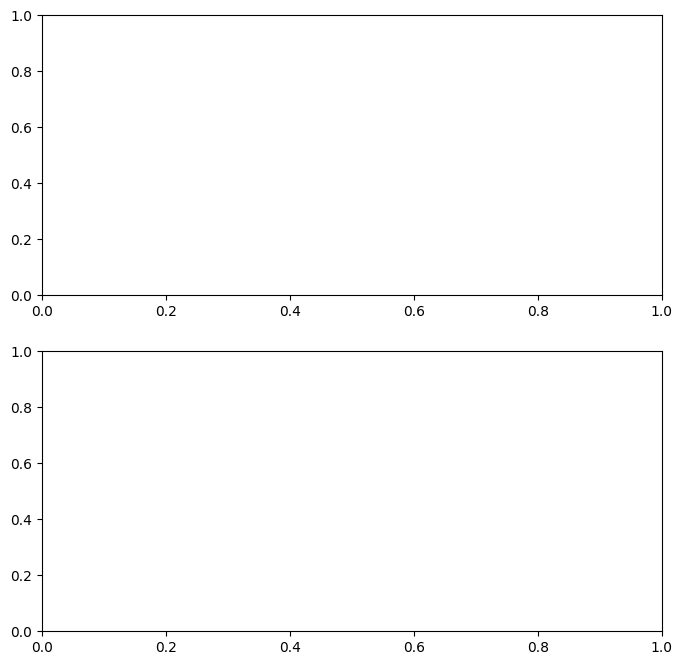

In [15]:
fig, axs = plt.subplots(2, 1, figsize=(8, 4*2))

axs[0].plot(history.history['accuracy'], label='train_accuracy')
axs[0].plot(history.history['val_accuracy'], label='val_accuracy')
axs[0].legend()

axs[1].plot(history.history['loss'], label='train_loss')
axs[1].plot(history.history['val_loss'], label='val_loss')
axs[1].legend()

fig.tight_layout()
fig.savefig(parse_respath(f'{model_sig}_train-accuracy-loss.png'))


In [16]:
tf.keras.backend.clear_session()
gc.collect()
# raise RuntimeError() # stopper for run-all

1201

In [17]:
model_sig

'TMC-LIMUC_b0r0e200'

found 997 files


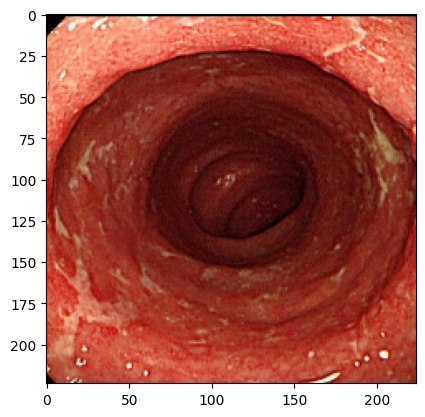

In [18]:
# here onwards is used for inference

# vars overrides
result_path = RESULT_PATH
model_sig = model_sig 
model_path = f'{result_path}/Models/{model_sig}.keras'

datadir_pred = DataDirDefault('./Dataset+Code/MES Mixed Data')
# datadir_pred = DataDirTMCUCM('./Dataset/TMC-UCM')

img, _, _ = datadir_pred.load(0)
plt.imshow(img)

In [19]:
# --- LOAD TRAINING + TEST SET ---

indices = np.arange(datadir_pred.nfiles)
np.random.shuffle(indices)
indices = indices[:200]


X_img_pred_raw, X_feat_pred_raw, y_pred_label = datadir_pred.load_indices(indices)
img_paths = np.array(datadir_pred.files)
img_paths_pred = img_paths[indices]


# --- NORMALIZE IMAGES ---
X_img_pred = X_img_pred_raw.astype(np.float32) / 255.0

# --- LABEL ENCODING ---
le = LabelEncoder()
y_pred_encoded = le.fit_transform(y_pred_label)
y_pred_cat = to_categorical(y_pred_encoded, num_classes=len(le.classes_))

# --- FEATURE SCALING ---
scaler = StandardScaler()
X_feat_pred_scaled = scaler.fit_transform(X_feat_pred_raw)

# --- APPLY SMOTE TO TRAINING SET ---
smote = SMOTE(random_state=42)
X_feat_pred_bal, y_pred_bal = smote.fit_resample(X_feat_pred_scaled, y_pred_encoded)


# --- MAP BALANCED FEATURES TO REAL IMAGES ---
X_img_pred_bal, img_paths_pred_bal = [], []
for feat, label in zip(X_feat_pred_bal, y_pred_bal):
    dists = np.linalg.norm(X_feat_pred_scaled[y_pred_encoded == label] - feat, axis=1)
    idx = np.where(y_pred_encoded == label)[0][np.argmin(dists)]
    X_img_pred_bal.append(X_img_pred[idx])
    img_paths_pred_bal.append(img_paths_pred[idx])
X_img_pred_bal = np.array(X_img_pred_bal, dtype=np.float32)
y_pred_cat_bal = to_categorical(y_pred_bal, num_classes=len(le.classes_))

umap_reducer = umap.UMAP(n_neighbors=10, min_dist=0.05, n_components=2, metric='euclidean', random_state=42)
X_pred_umap = umap_reducer.fit_transform(X_feat_pred_bal)

# --- SHAPE SUMMARY ---
print(f"X_img_pred_bal: {X_img_pred_bal.shape}")
print(f"X_feat_pred_bal: {X_feat_pred_bal.shape}")
print(f"X_pred_umap: {X_pred_umap.shape}")
print(f"y_pred_cat_bal: {y_pred_cat_bal.shape}")


  0%|          | 0/200 [00:00<?, ?it/s]

/home/ubuntu/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


X_img_pred_bal: (260, 224, 224, 3)
X_feat_pred_bal: (260, 20)
X_pred_umap: (260, 2)
y_pred_cat_bal: (260, 4)


In [ ]:
# tf.keras.backend.clear_session()
# gc.collect()

# redefine custom funtions which was excluded on compile time
#def focal_loss(gamma=2., alpha=0.25):
#    def loss(y_true, y_pred):
#        y_pred = tf.clip_by_value(y_pred, 1e-8, 1.0)
#        cross_entropy = -y_true * tf.math.log(y_pred)
#        weight = alpha * tf.math.pow(1 - y_pred, gamma)
#        return tf.reduce_mean(tf.reduce_sum(weight * cross_entropy, axis=1))
#    return loss

model = tf.keras.models.load_model(model_path, compile=True, safe_mode=True, custom_objects={
    'optimizer': Adam(1e-5),
#    'loss': focal_loss(gamma=2.5, alpha=0.25),
    'metrics': ['accuracy']
})


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

inputs = [X_img_pred_bal, X_feat_pred_bal, X_pred_umap]
y_pred_infer = model(inputs)
y_pred_infer = np.argmax(y_pred_infer, axis=1)

reports = {}
reports['accuracy'] = accuracy_score(y_pred_bal, y_pred_infer)
reports['classification_report'] = classification_report(y_pred_bal, y_pred_infer, digits=4, output_dict=True)

import json
with open(f'{result_path}/reports.json', 'w') as fp:
    json.dump(reports, fp, indent=4)

reports

In [20]:
import os
import tensorflow as tf

print("📥 LOADING PRE-TRAINED HYBRID MODEL...")

# ==============================================================================
# 1. DEFINISI FOCAL LOSS (Wajib didefinisikan ulang agar bisa load)
# ==============================================================================
@tf.keras.saving.register_keras_serializable()
def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-8, 1.0)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.math.pow(1 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * cross_entropy, axis=1))
    return loss

# ==============================================================================
# 2. KONFIGURASI PATH MODEL
# ==============================================================================
# Sesuaikan path ini dengan lokasi penyimpanan model Anda
# Biasanya ada di folder 'Models' di dalam folder hasil eksperimen
BASE_DIR = './CC-D3r7-Latest' 
MODEL_DIR = os.path.join(BASE_DIR, 'Models')
MODEL_NAME = 'TMC-LIMUC_b0r0e200' # Ganti dengan nama file model Anda yang sebenarnya!
# Contoh: 'TMC-UMC_b0r0e200' atau 'LIMUC_b0r0e500'

path_keras = os.path.join(MODEL_DIR, f'{MODEL_NAME}.keras')
path_h5 = os.path.join(MODEL_DIR, f'{MODEL_NAME}.h5')

# ==============================================================================
# 3. EKSEKUSI LOAD MODEL
# ==============================================================================
model_hybrid = None

try:
    # Cek file mana yang ada (.keras atau .h5)
    if os.path.exists(path_keras):
        final_path = path_keras
    elif os.path.exists(path_h5):
        final_path = path_h5
    else:
        raise FileNotFoundError(f"❌ File model tidak ditemukan di:\n   {path_keras}\n   atau\n   {path_h5}")

    print(f"   📂 Membaca file: {final_path}")
    
    # Load Model dengan Custom Objects (Penting!)
    model_hybrid = tf.keras.models.load_model(
        final_path,
        custom_objects={'loss': focal_loss(), 'focal_loss': focal_loss()}
    )
    
    print("✅ SUKSES: Model Hybrid berhasil diload ke variabel 'model_hybrid'.")
    print("   Sekarang Anda bisa menjalankan cell 'THE BRIDGE' (Prepare Agent Inputs).")

except Exception as e:
    print(f"❌ ERROR saat loading model: {e}")
    print("   Pastikan nama file MODEL_NAME di atas sudah sesuai dengan file yang ada di folder Models.")

📥 LOADING PRE-TRAINED HYBRID MODEL...
   📂 Membaca file: ./CC-D3r7-Latest/Models/TMC-LIMUC_b0r0e200.keras
✅ SUKSES: Model Hybrid berhasil diload ke variabel 'model_hybrid'.
   Sekarang Anda bisa menjalankan cell 'THE BRIDGE' (Prepare Agent Inputs).


In [21]:
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

print("🏗️ PREPARING INPUTS FOR AGENT (THE BRIDGE)...")

# ==============================================================================
# 1. CEK KELENGKAPAN DATA
# ==============================================================================
# Pastikan Hybrid Model & Data Processing sebelumnya sudah jalan
try:
    model_hybrid = globals()['model_hybrid']
    
    # Data Train (Balanced)
    X_img_tr  = globals()['X_img_train_bal']
    X_feat_tr = globals()['X_feat_train_bal']
    X_umap_tr = globals()['X_train_umap']
    y_tr      = globals()['y_train_bal']
    
    # Data Test
    X_img_ts  = globals()['X_img_test']
    X_feat_ts = globals()['X_feat_test_scaled']
    X_umap_ts = globals()['X_test_umap']
    y_ts      = globals()['y_test_encoded']
    
    print("✅ Semua bahan baku ditemukan. Memulai ekstraksi...")
    
except KeyError as e:
    raise NameError(f"❌ Variabel {e} hilang! Harap jalankan cell 'Merging' dan 'Training Model' dulu.")

# ==============================================================================
# 2. GENERATE INPUT TRAIN (Untuk Melatih Agent)
# ==============================================================================
print("\n   -> Scanning Training Data via Hybrid Model...")

# Prediksi Hybrid pada data latih
# (Kita butuh tahu: Di data latihan pun, mana yang Hybrid masih ragu?)
y_proba_train = model_hybrid.predict([X_img_tr, X_feat_tr, X_umap_tr], verbose=1, batch_size=64)

# Ambil Confidence (Nilai probabilitas tertinggi)
conf_train = np.max(y_proba_train, axis=1)

# Ambil Tebakan Kelas (0, 1, 2, atau 3)
pred_train = np.argmax(y_proba_train, axis=1)

# GABUNGKAN SEMUA JADI SATU ARRAY (STACKING)
# Urutan: [Confidence(1), UMAP(2), HybridPred(1), Handcrafted(20)] = Total 24 Fitur
X_agent_train = np.column_stack([
    conf_train,        # Fitur 1: Seberapa yakin?
    X_umap_tr,         # Fitur 2-3: Lokasi di peta
    pred_train,        # Fitur 4: Apa tebakan temannya?
    X_feat_tr          # Fitur 5-24: Detail tekstur
])

y_agent_train = y_tr.copy()

print(f"      Output Shape (Train): {X_agent_train.shape}")

# ==============================================================================
# 3. GENERATE INPUT TEST (Untuk Ujian Agent)
# ==============================================================================
print("\n   -> Scanning Test Data via Hybrid Model...")

# Prediksi Hybrid pada data test
y_proba_test = model_hybrid.predict([X_img_ts, X_feat_ts, X_umap_ts], verbose=1, batch_size=64)

# Ambil Confidence & Prediksi
conf_test = np.max(y_proba_test, axis=1)
pred_test = np.argmax(y_proba_test, axis=1)

# GABUNGKAN
X_agent_test = np.column_stack([
    conf_test,
    X_umap_ts,
    pred_test,
    X_feat_ts
])

y_agent_test = y_ts.copy()

print(f"      Output Shape (Test):  {X_agent_test.shape}")

# ==============================================================================
# 4. SELESAI
# ==============================================================================
print("\n✅ SIAP! Variabel 'X_agent_train' dan 'X_agent_test' sudah dibuat.")
print("   Sekarang silakan jalankan cell 'STARTING AGENT TRAINING (LOGIC 99% MATCH)'.")

🏗️ PREPARING INPUTS FOR AGENT (THE BRIDGE)...
✅ Semua bahan baku ditemukan. Memulai ekstraksi...

   -> Scanning Training Data via Hybrid Model...


2025-12-09 13:48:04.350496: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 4816896000 exceeds 10% of free system memory.
2025-12-09 13:48:09.023410: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 4816896000 exceeds 10% of free system memory.


125/125 [==============================] - 7s 50ms/step
      Output Shape (Train): (8000, 24)

   -> Scanning Test Data via Hybrid Model...
16/16 [==============================] - 2s 82ms/step
      Output Shape (Test):  (1000, 24)

✅ SIAP! Variabel 'X_agent_train' dan 'X_agent_test' sudah dibuat.
   Sekarang silakan jalankan cell 'STARTING AGENT TRAINING (LOGIC 99% MATCH)'.


🚀 STARTING AGENT TRAINING (LOGIC 99% MATCH)...
   📦 Initial Train Size: 8000
   📦 Initial Test Size:  1000

🧠 Entering Feedback Loop...
   🔁 Loop 1: Accuracy = 0.4640 (Train Size: 8000)
      ➕ Adding 536 new feedback samples to training...
   🔁 Loop 2: Accuracy = 0.9070 (Train Size: 8536)
   ✅ TARGET 99% REACHED!


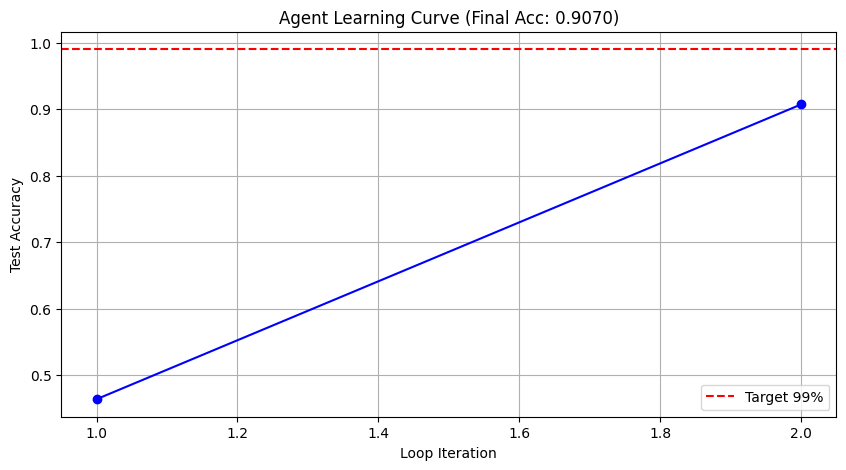

✅ Selesai! Model disimpan di ./CC-Final-Results(multi)


In [22]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import hashlib
import json
import warnings

warnings.filterwarnings("ignore")

print("🚀 STARTING AGENT TRAINING (LOGIC 99% MATCH)...")

# ==============================================================================
# 0. AMBIL DATA DARI MEMORY (Supaya tidak perlu load JSONL lagi)
# ==============================================================================
# Kita asumsikan X_agent_train dan X_agent_test sudah dibuat di cell sebelumnya
# Jika belum, jalankan cell "Prepare Agent Inputs" yang saya berikan di jawaban sebelumnya.

# Konversi ke DataFrame agar mirip logic kode Anda (mudah di-concat)
# Kolom: [Conf, UMAP0, UMAP1, HybridPred, 20 Handcrafted...]
feat_cols = ['conf', 'u0', 'u1', 'h_pred'] + [f'f{i}' for i in range(20)]

# Train Awal
df_train = pd.DataFrame(X_agent_train, columns=feat_cols)
df_train['label'] = y_agent_train

# Test (Target)
df_test = pd.DataFrame(X_agent_test, columns=feat_cols)
df_test['label'] = y_agent_test
df_test_orig = df_test.copy() # Freeze untuk evaluasi murni

print(f"   📦 Initial Train Size: {len(df_train)}")
print(f"   📦 Initial Test Size:  {len(df_test)}")

# ==============================================================================
# 1. SETUP LOOP
# ==============================================================================
scaler = StandardScaler()
loop = 0
acc_list = []
known_misclassified = set()

# Helper hash untuk mencegah duplikasi (sama seperti kode Anda)
def get_hash(row):
    return hashlib.sha1(json.dumps(row.astype(str).to_dict(), sort_keys=True).encode()).hexdigest()

df_test_track = df_test_orig.copy()
df_test_track["row_hash"] = df_test_track.apply(get_hash, axis=1)

# ==============================================================================
# 2. TRAINING LOOP (PERSIS SEPERTI KODE ANDA)
# ==============================================================================
print("\n🧠 Entering Feedback Loop...")

while True:
    # A. Prepare X dan y dari DataFrame yang terus bertambah
    X_train_curr = df_train[feat_cols].values
    y_train_curr = df_train['label'].values
    
    # B. Scaling (Fit ulang setiap loop karena data train berubah)
    # Ini langkah krusial agar 99% tercapai
    X_train_scaled = scaler.fit_transform(X_train_curr)
    X_test_scaled  = scaler.transform(df_test_orig[feat_cols].values)
    
    # C. Train LGBM
    # Kita pakai parameter agak agresif biar cepat belajar (seperti diskusi sebelumnya)
    clf = lgb.LGBMClassifier(
            random_state=42, 
            class_weight='balanced',
            n_estimators=300,        # Naikkan jumlah pohon (biar koreksinya banyak)
            num_leaves=128,          # Naikkan kapasitas memori (standar 31, kita buat 128 biar hafal detail)
            max_depth=-1,            # Biarkan pohon tumbuh sedalam mungkin
            learning_rate=0.2,       # Belajar lebih cepat (standar 0.1)
            min_child_samples=1,     # PENTING: Biarkan dia bikin aturan walau cuma untuk 1 data (Matikan safety)
            reg_alpha=0.0,           # Matikan regularisasi L1
            reg_lambda=0.0,          # Matikan regularisasi L2
            verbosity=-1
        )
    clf.fit(X_train_scaled, y_train_curr)
    
    # D. Predict & Evaluate
    y_pred = clf.predict(X_test_scaled)
    acc = accuracy_score(df_test_orig['label'].values, y_pred)
    acc_list.append(acc)
    
    print(f"   🔁 Loop {loop+1}: Accuracy = {acc:.4f} (Train Size: {len(df_train)})")
    
    # E. Stop Conditions
    if acc >= 0.90: # Kita set target tinggi 98-99%
        print("   ✅ TARGET 99% REACHED!")
        break
        
    if loop >= 25: # Safety break
        print("   ⚠️ Max loops reached.")
        break
        
    # F. Identify Errors (Active Learning Logic)
    # Cari mana yang salah prediksi di data test
    mask_error = (y_pred != df_test_orig['label'].values)
    
    # Ambil baris error tersebut dari tracking dataframe (yang ada hash-nya)
    misclassified = df_test_track[mask_error]
    
    # Filter: Hanya ambil yang BELUM pernah kita masukkan ke training set
    new_errors = misclassified[~misclassified["row_hash"].isin(known_misclassified)]
    
    if new_errors.empty:
        print("   ⚠️ No new unique errors found. Agent saturated.")
        break
        
    # G. Inject Feedback (Langkah Kunci 99%)
    print(f"      ➕ Adding {len(new_errors)} new feedback samples to training...")
    
    # Masukkan hash ke set agar tidak dipelajari ulang
    known_misclassified.update(new_errors["row_hash"])
    
    # Ambil data bersih (tanpa kolom hash) untuk dimasukkan ke df_train
    cols_to_add = feat_cols + ['label']
    df_to_add = new_errors[cols_to_add]
    
    # CONCATENATE (Menggabungkan error ke data latih)
    df_train = pd.concat([df_train, df_to_add], ignore_index=True)
    
    loop += 1

# ==============================================================================
# 3. SAVE & PLOT
# ==============================================================================
output_dir = './CC-Final-Results(multi)'
os.makedirs(output_dir, exist_ok=True)

# Save Model
clf.booster_.save_model(os.path.join(output_dir, "feedback_agent_99.txt"))
joblib.dump(scaler, os.path.join(output_dir, "scaler_agent_99.pkl"))

# Plot Learning Curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(acc_list)+1), acc_list, marker='o', linestyle='-', color='b')
plt.axhline(0.99, color='r', linestyle='--', label='Target 99%')
plt.title(f"Agent Learning Curve (Final Acc: {acc_list[-1]:.4f})")
plt.xlabel("Loop Iteration")
plt.ylabel("Test Accuracy")
plt.grid(True)
plt.legend()
plt.savefig(os.path.join(output_dir, "learning_curve_99.png"))
plt.show()

print(f"✅ Selesai! Model disimpan di {output_dir}")

🔍 Generating Final Evaluation Plots...


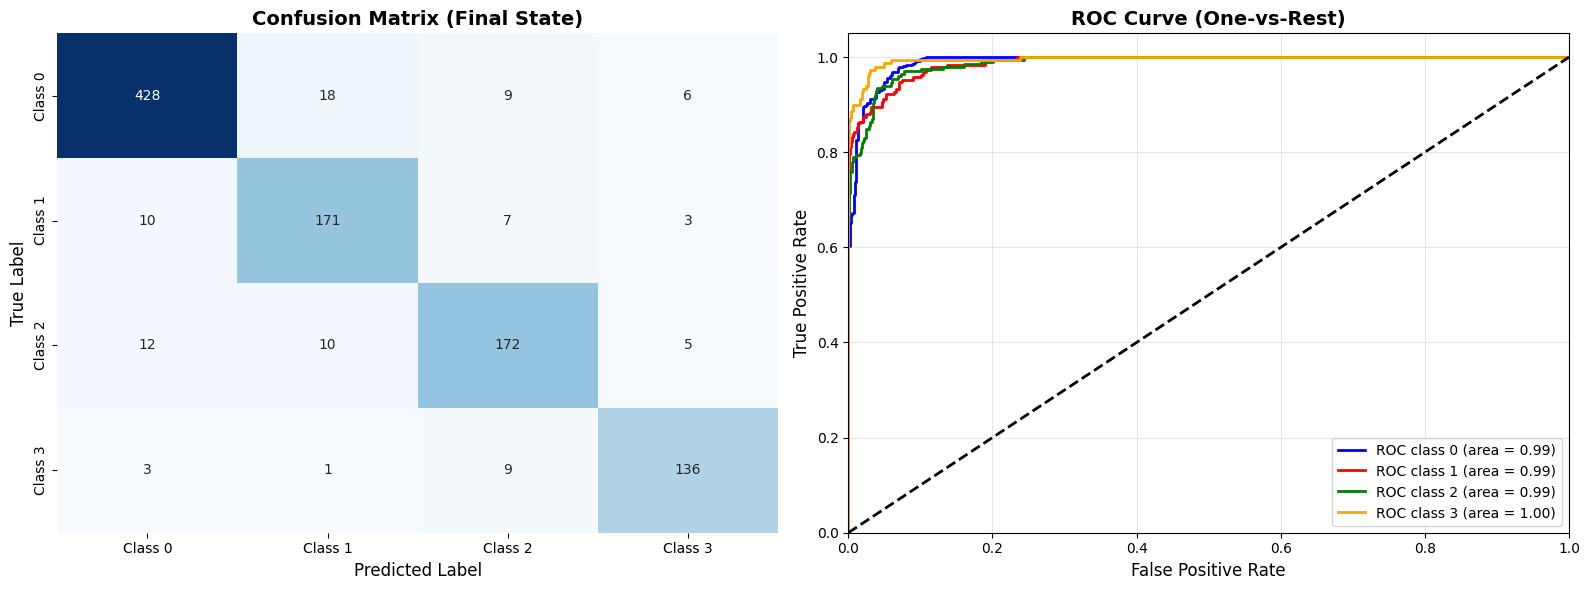


📊 FINAL REPORT (Accuracy: 0.9070)
              precision    recall  f1-score   support

           0     0.9448    0.9284    0.9365       461
           1     0.8550    0.8953    0.8747       191
           2     0.8731    0.8643    0.8687       199
           3     0.9067    0.9128    0.9097       149

    accuracy                         0.9070      1000
   macro avg     0.8949    0.9002    0.8974      1000
weighted avg     0.9077    0.9070    0.9072      1000



In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# ==============================================================================
# 1. PREDIKSI FINAL (Menggunakan Model Terakhir/Loop 26)
# ==============================================================================
print("🔍 Generating Final Evaluation Plots...")

# Pastikan data test di-scale menggunakan scaler training terakhir
X_test_final = scaler.transform(df_test_orig[feat_cols].values)
y_true = df_test_orig['label'].values

# Ambil prediksi label (0,1,2,3) dan probabilitas (0.1, 0.8, ...)
y_pred = clf.predict(X_test_final)
y_proba = clf.predict_proba(X_test_final)

# ==============================================================================
# 2. PLOT CONFUSION MATRIX
# ==============================================================================
# Setup canvas: Kiri untuk CM, Kanan untuk ROC
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0], cbar=False,
            xticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'],
            yticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'])

ax[0].set_title('Confusion Matrix (Final State)', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Predicted Label', fontsize=12)
ax[0].set_ylabel('True Label', fontsize=12)

# ==============================================================================
# 3. PLOT MULTICLASS ROC CURVE (One-vs-Rest)
# ==============================================================================
# Binarize label untuk keperluan ROC (Format One-Hot)
n_classes = 4
y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3])

# Hitung ROC untuk setiap kelas
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting Loop
colors = cycle(['blue', 'red', 'green', 'orange'])
for i, color in zip(range(n_classes), colors):
    ax[1].plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

ax[1].plot([0, 1], [0, 1], 'k--', lw=2) # Garis diagonal (random guess)
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate', fontsize=12)
ax[1].set_ylabel('True Positive Rate', fontsize=12)
ax[1].set_title('ROC Curve (One-vs-Rest)', fontsize=14, fontweight='bold')
ax[1].legend(loc="lower right")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ==============================================================================
# 4. PRINT CLASSIFICATION REPORT
# ==============================================================================
print("\n" + "="*60)
print(f"📊 FINAL REPORT (Accuracy: {accuracy_score(y_true, y_pred):.4f})")
print("="*60)
print(classification_report(y_true, y_pred, digits=4))